STN (Spatial Transformer Network)

Learns an affine transform (shift, scale, rotate)

affine_grid + grid_sample applies the transform.

ViT Block

Divides image into 7×7 patches.

Uses Multi‑Head Attention to learn relationships.

Outputs classification into 10 MNIST digits.

Combined Model (STN + ViT)

First applies affine correction → then classifies.

Dataset

MNIST, only 200 images, split 80–20.

Training

Runs 5 epochs quickly.

Visualization

Shows original vs STN‑transformed images for 4 samples.

Epoch 1, Loss: 2.3067
Epoch 2, Loss: 2.2786
Epoch 3, Loss: 2.2350
Epoch 4, Loss: 2.1260
Epoch 5, Loss: 1.8647
Training complete!
Test Accuracy: 55.00%


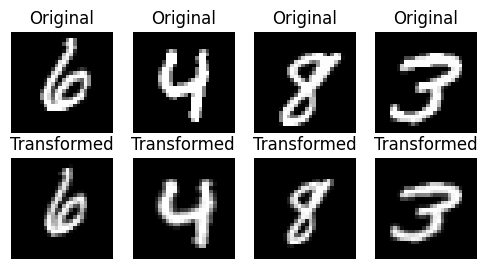

In [1]:
"""
Skill Program 3: Spatial Transformer Network (STN) + Vision Transformer (ViT)
-----------------------------------------------------------------------------
This program implements:
1. A Spatial Transformer Network (STN) for affine transformation of images.
2. A simple Vision Transformer (ViT) block for classification.
Dataset: MNIST (only 200 images, auto-downloaded).
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Step 1: Define the Spatial Transformer Network (STN)
class STN(nn.Module):
    def __init__(self):
        super(STN, self).__init__()
        # Localization network
        self.localization = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=7), nn.MaxPool2d(2, stride=2), nn.ReLU(),
            nn.Conv2d(8, 10, kernel_size=5), nn.MaxPool2d(2, stride=2), nn.ReLU()
        )
        # Regressor for 2x3 affine matrix
        self.fc_loc = nn.Sequential(
            nn.Linear(10 * 3 * 3, 32), nn.ReLU(),
            nn.Linear(32, 6)
        )
        # Initialize to identity transform
        self.fc_loc[2].weight.data.zero_()
        self.fc_loc[2].bias.data.copy_(torch.tensor([1,0,0,0,1,0], dtype=torch.float))

    def forward(self, x):
        xs = self.localization(x)
        xs = xs.view(-1, 10 * 3 * 3)
        theta = self.fc_loc(xs).view(-1, 2, 3)  # affine matrix
        grid = nn.functional.affine_grid(theta, x.size(), align_corners=False)
        x = nn.functional.grid_sample(x, grid, align_corners=False)
        return x

# Step 2: Define a simple Vision Transformer block
class ViTBlock(nn.Module):
    def __init__(self, embed_dim=64, num_heads=4, num_classes=10):
        super(ViTBlock, self).__init__()
        self.patch_embed = nn.Linear(7*7, embed_dim)   # Flatten patch
        self.mha = nn.MultiheadAttention(embed_dim, num_heads)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # Flatten into patches: [batch, channels, height, width] -> patches
        x = nn.functional.unfold(x, kernel_size=7, stride=7)  # divide into 7x7 patches
        x = x.transpose(1,2)   # [batch, num_patches, patch_dim]
        x = self.patch_embed(x) # project to embed_dim
        x = x.transpose(0,1)    # [num_patches, batch, embed_dim] for MHA
        attn_out, _ = self.mha(x, x, x)
        x = attn_out.mean(dim=0) # average across patches
        out = self.fc(x)
        return out

# Step 3: Combine STN + ViT
class STN_ViT(nn.Module):
    def __init__(self):
        super(STN_ViT, self).__init__()
        self.stn = STN()
        self.vit = ViTBlock()

    def forward(self, x):
        x = self.stn(x)   # apply spatial transformation
        x = self.vit(x)   # classify with ViT
        return x

# Step 4: Load MNIST dataset (200 images only)
transform = transforms.Compose([
    transforms.Resize((28,28)),
    transforms.ToTensor()
])
full_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
subset_indices = list(range(200))
small_dataset = Subset(full_dataset, subset_indices)

# Split 80-20
train_size = int(0.8 * len(small_dataset))
test_size = len(small_dataset) - train_size
train_set, test_set = random_split(small_dataset, [train_size, test_size])
trainloader = DataLoader(train_set, batch_size=8, shuffle=True)
testloader = DataLoader(test_set, batch_size=8, shuffle=False)

# Step 5: Initialize model, loss, optimizer
model = STN_ViT()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Step 6: Train for 5 epochs
for epoch in range(5):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")

print("Training complete!")

# Step 7: Evaluate on test set
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Test Accuracy: {100*correct/total:.2f}%")

# Step 8: Visualize STN transformation
images, _ = next(iter(testloader))
with torch.no_grad():
    transformed = model.stn(images)

plt.figure(figsize=(6,3))
for i in range(4):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i][0], cmap="gray")
    plt.title("Original")
    plt.axis("off")
    plt.subplot(2,4,i+5)
    plt.imshow(transformed[i][0], cmap="gray")
    plt.title("Transformed")
    plt.axis("off")
plt.show()
